# Statistics for Michel electron candidate (28116 full run)

### Created by Shu, 20251130---

### To fulfill the requirement of Anselmo!

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## PeakFinder (based on merged wvfCoin result):

In [3]:
import matplotlib.pyplot as plt
import numpy as np


peakFinder_muTime = []
peakFinder_miTime = []
peakFinder_miCoin = []

# Open the text file and process each line
with open('./statResult_MSp6/peakFinder_muonTime.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_muTime.append(number)
            except ValueError:
                print(f"[Muon] Could not convert {parts[1].strip()} to an integer.")

with open('./statResult_MSp6/peakFinder_michelTime.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_miTime.append(number)
            except ValueError:
                print(f"[Michel] Could not convert {parts[1].strip()} to an integer.")

with open('./statResult_MSp6/peakFinder_michelCoincidence.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_miCoin.append(number)
            except ValueError:
                print(f"[Coin] Could not convert {parts[1].strip()} to an integer.")




#Muon lifetime---
# Element-wise subtraction: (mi - mu) for each corresponding element
mu_lifetime = [mi - mu for mi, mu in zip(peakFinder_miTime, peakFinder_muTime)]






print("Length of peakFinder_muTime:", len(peakFinder_muTime))
print("Length of peakFinder_miTime:", len(peakFinder_miTime))
print("Length of peakFinder_miCoin:", len(peakFinder_miCoin))
print("\nLength of mu_lifetime: ", len(mu_lifetime))




Length of peakFinder_muTime: 5554
Length of peakFinder_miTime: 5554
Length of peakFinder_miCoin: 5554

Length of mu_lifetime:  5554


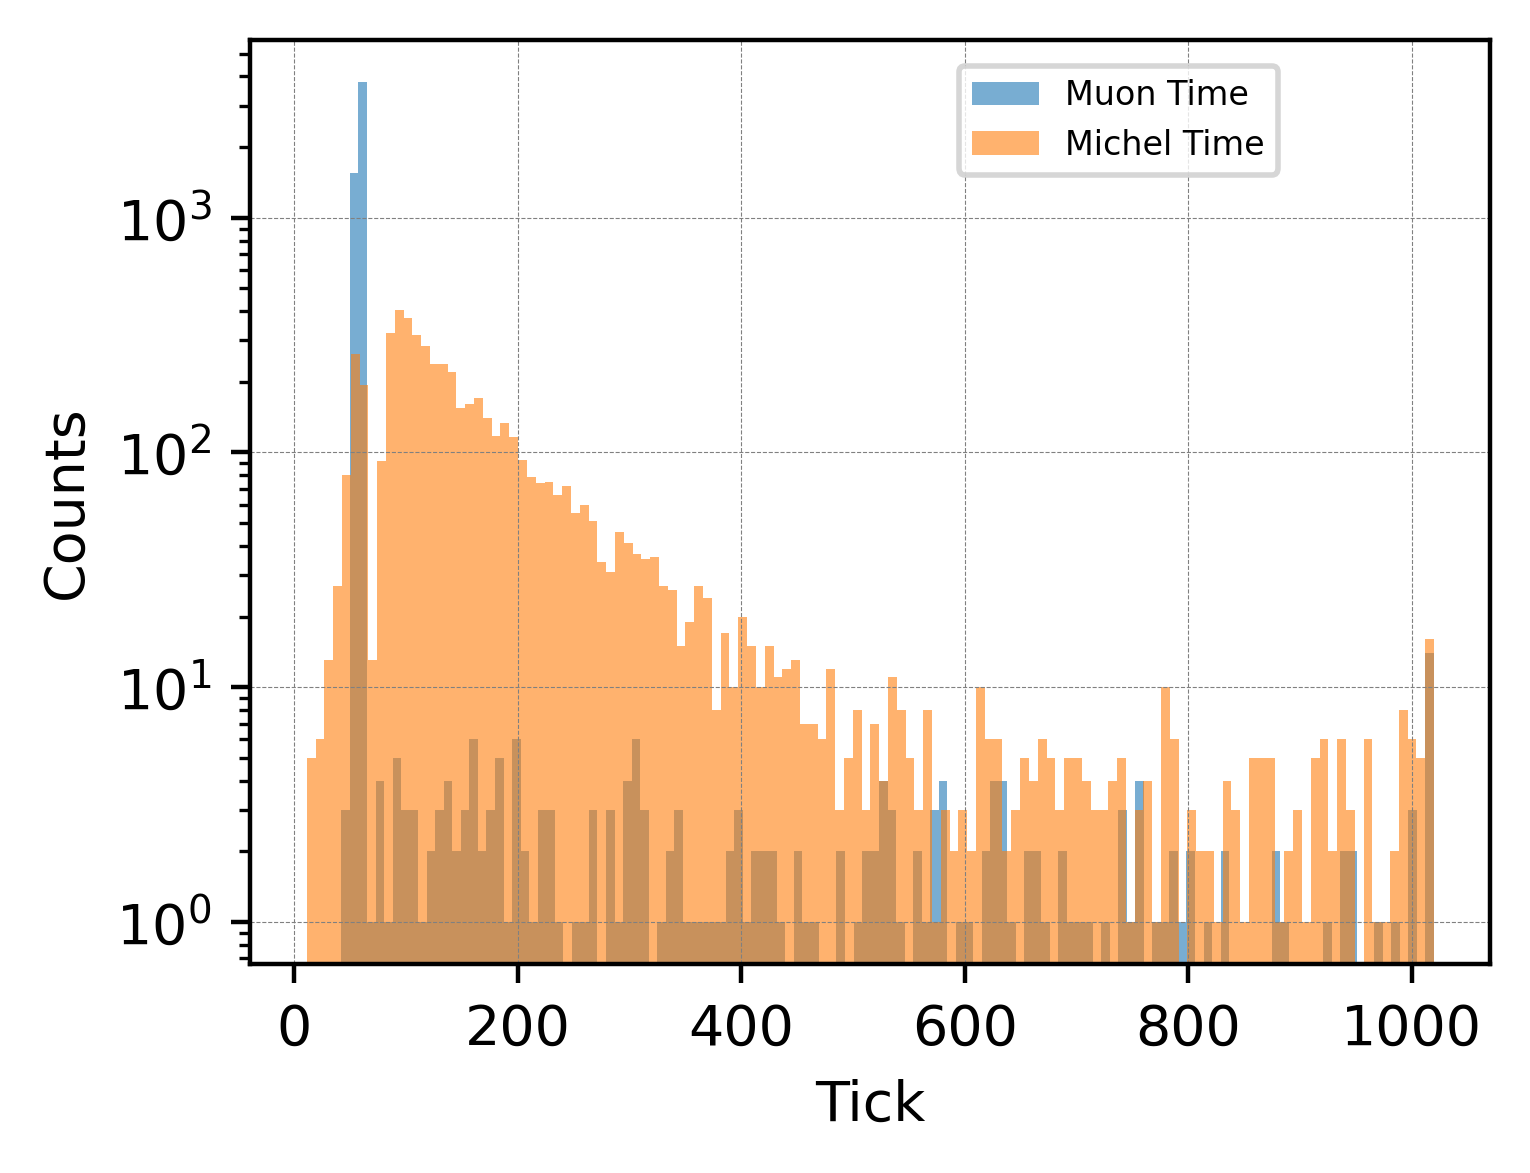


Lifetime distribution:
# Initial Candidates [-16000, 16000]:  5554
# Initial Candidates [0, 16000]:  5076 (91.39%)


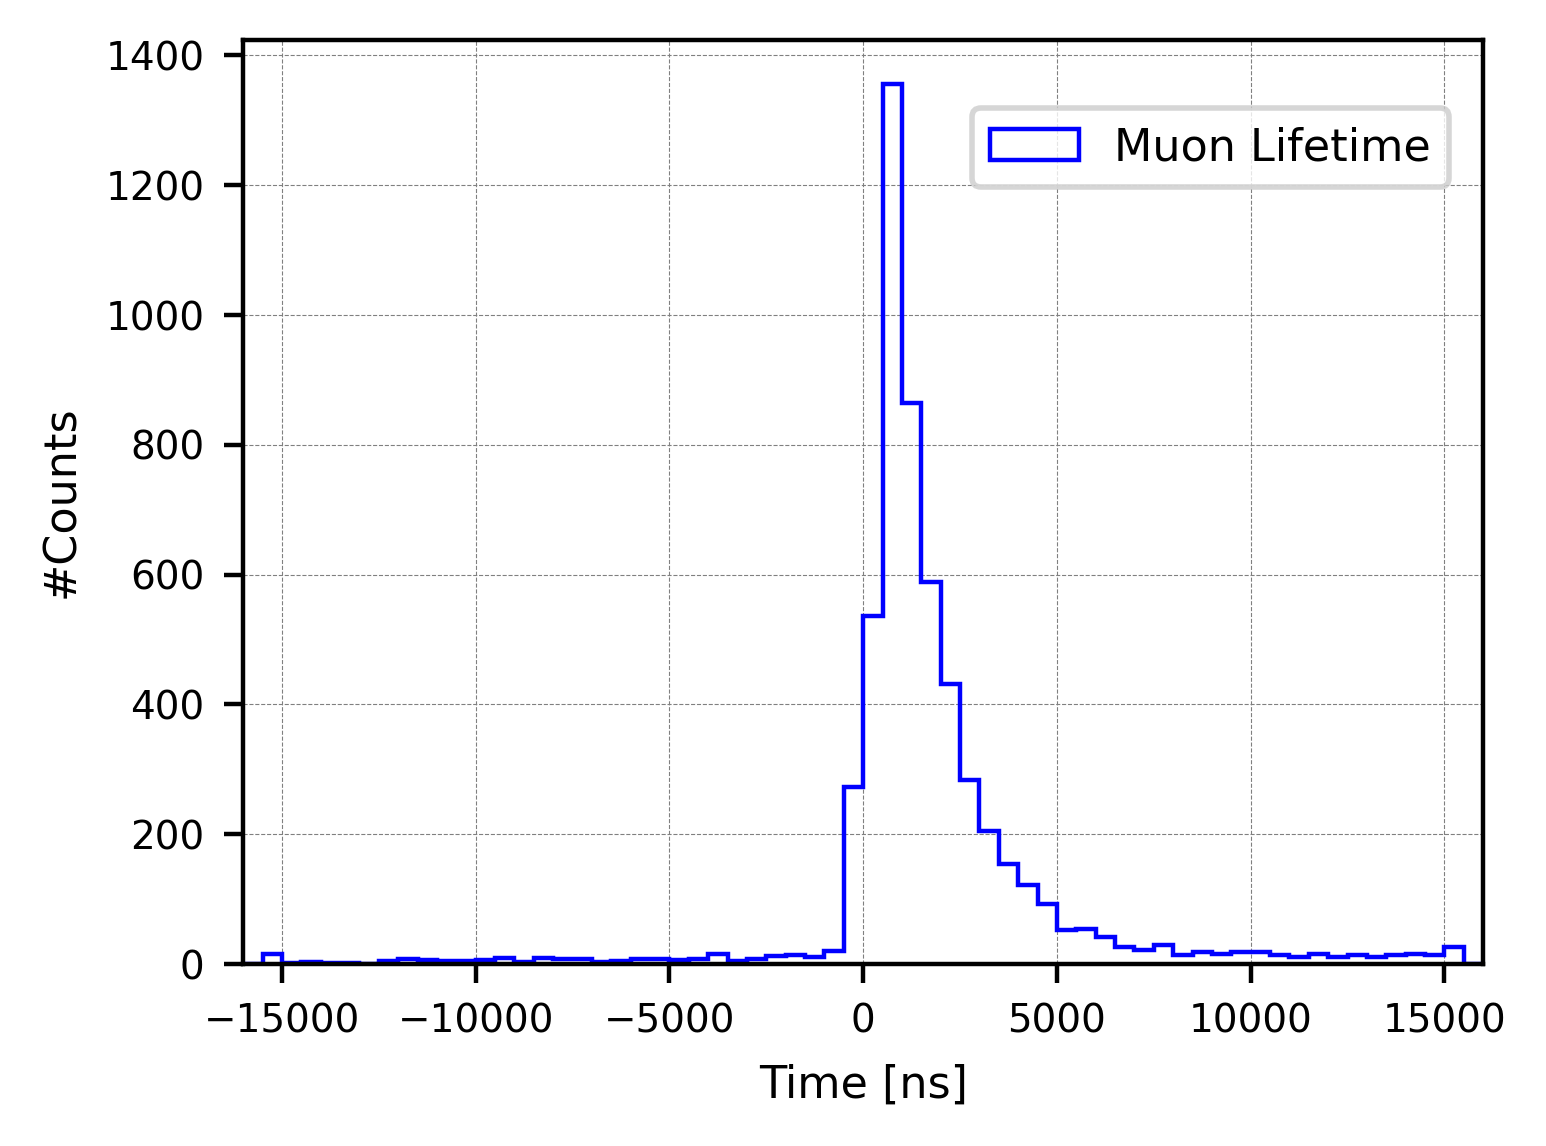

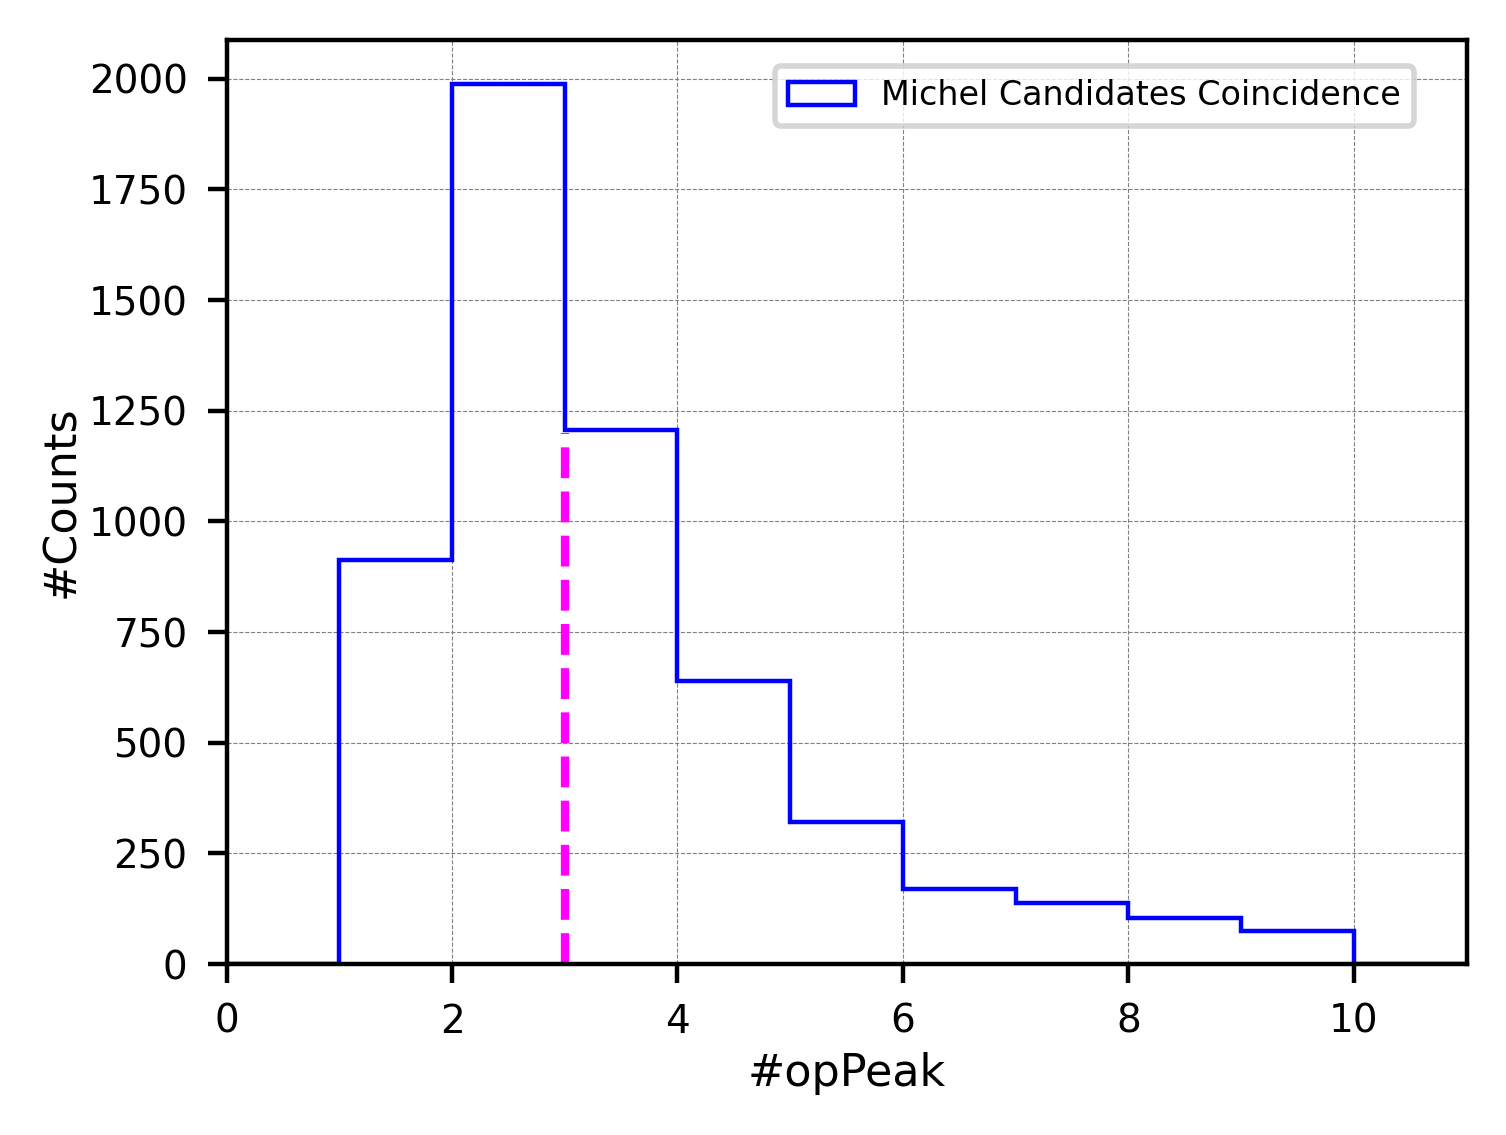

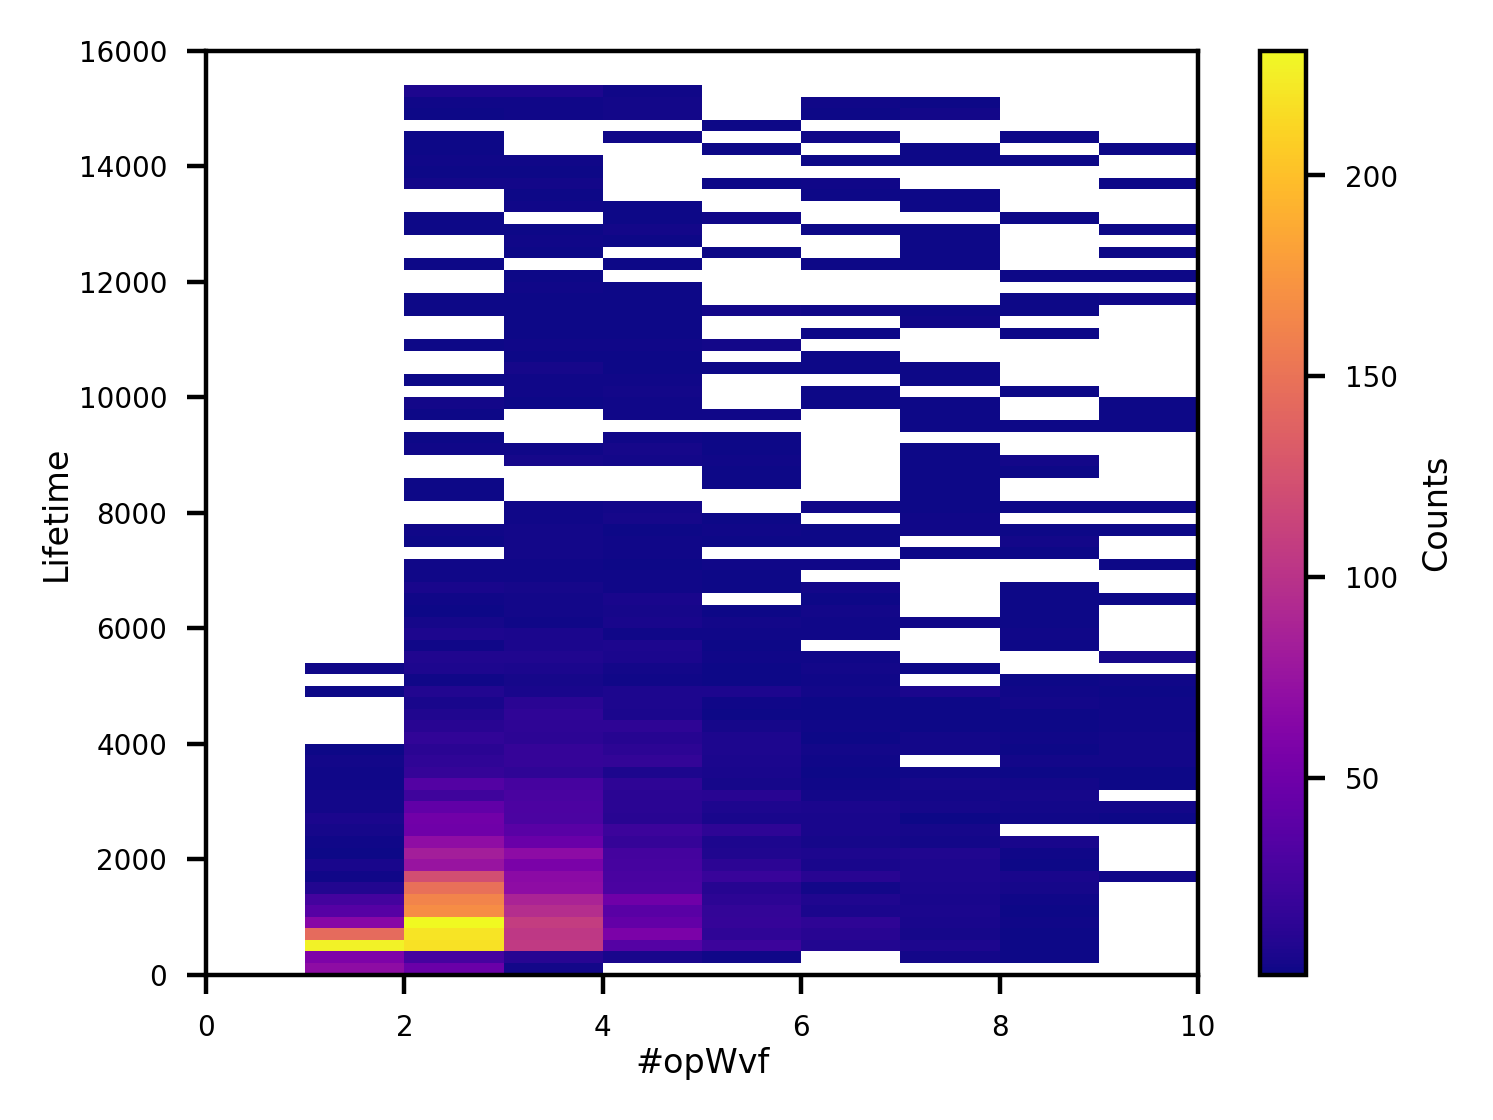

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Plot histograms on the same canvas
plt.hist(peakFinder_muTime, bins=128, alpha=0.6, label='Muon Time')
plt.hist(peakFinder_miTime, bins=128, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
#plt.title('Histogram of muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()








# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
mu_lifetime_ns = [value * 16 for value in mu_lifetime]
print("\nLifetime distribution:")
print("# Initial Candidates [-16000, 16000]: ", len(mu_lifetime_ns))

# Apply test cut
mu_lifetime_ns_test = [val for val in mu_lifetime_ns if 0 < val < 16000]
print("# Initial Candidates [0, 16000]: ", len(mu_lifetime_ns_test), "({:.2f}%)".format(len(mu_lifetime_ns_test)/len(mu_lifetime_ns)*100))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mu_lifetime_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Muon Lifetime')

plt.xlim(-16000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()









# Michel coincidence distribution------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([3, 3], [0, 1200], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(peakFinder_miCoin, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=0.8, label='Michel Candidates Coincidence')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

plt.xlim(0, 11)
#plt.ylim(0, 1200)
plt.xlabel('#opPeak', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 






#Lifetime vs opWvf (Original)===============================================

plt.figure(figsize=(4,3),dpi=400)



# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(peakFinder_miCoin, mu_lifetime_ns, bins=(10, 160), range=[[0, 10], [-16000, 16000]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

# Labels and styling
plt.xlim(0, 10)
plt.ylim(0, 16000) #(-16000, 16000)
plt.xlabel('#opWvf', labelpad=1, fontsize=6)
plt.ylabel('Lifetime', labelpad=1, fontsize=6)
#plt.title('After Space Cut', fontsize=7)
plt.tick_params(labelsize=5)




Keep #coincidence >=  5 :
# Purified Candidates [-16000, 16000]:  808
# Purified Candidates [0, 16000]:  668
# Purified Candidates [500, 16000]:  651


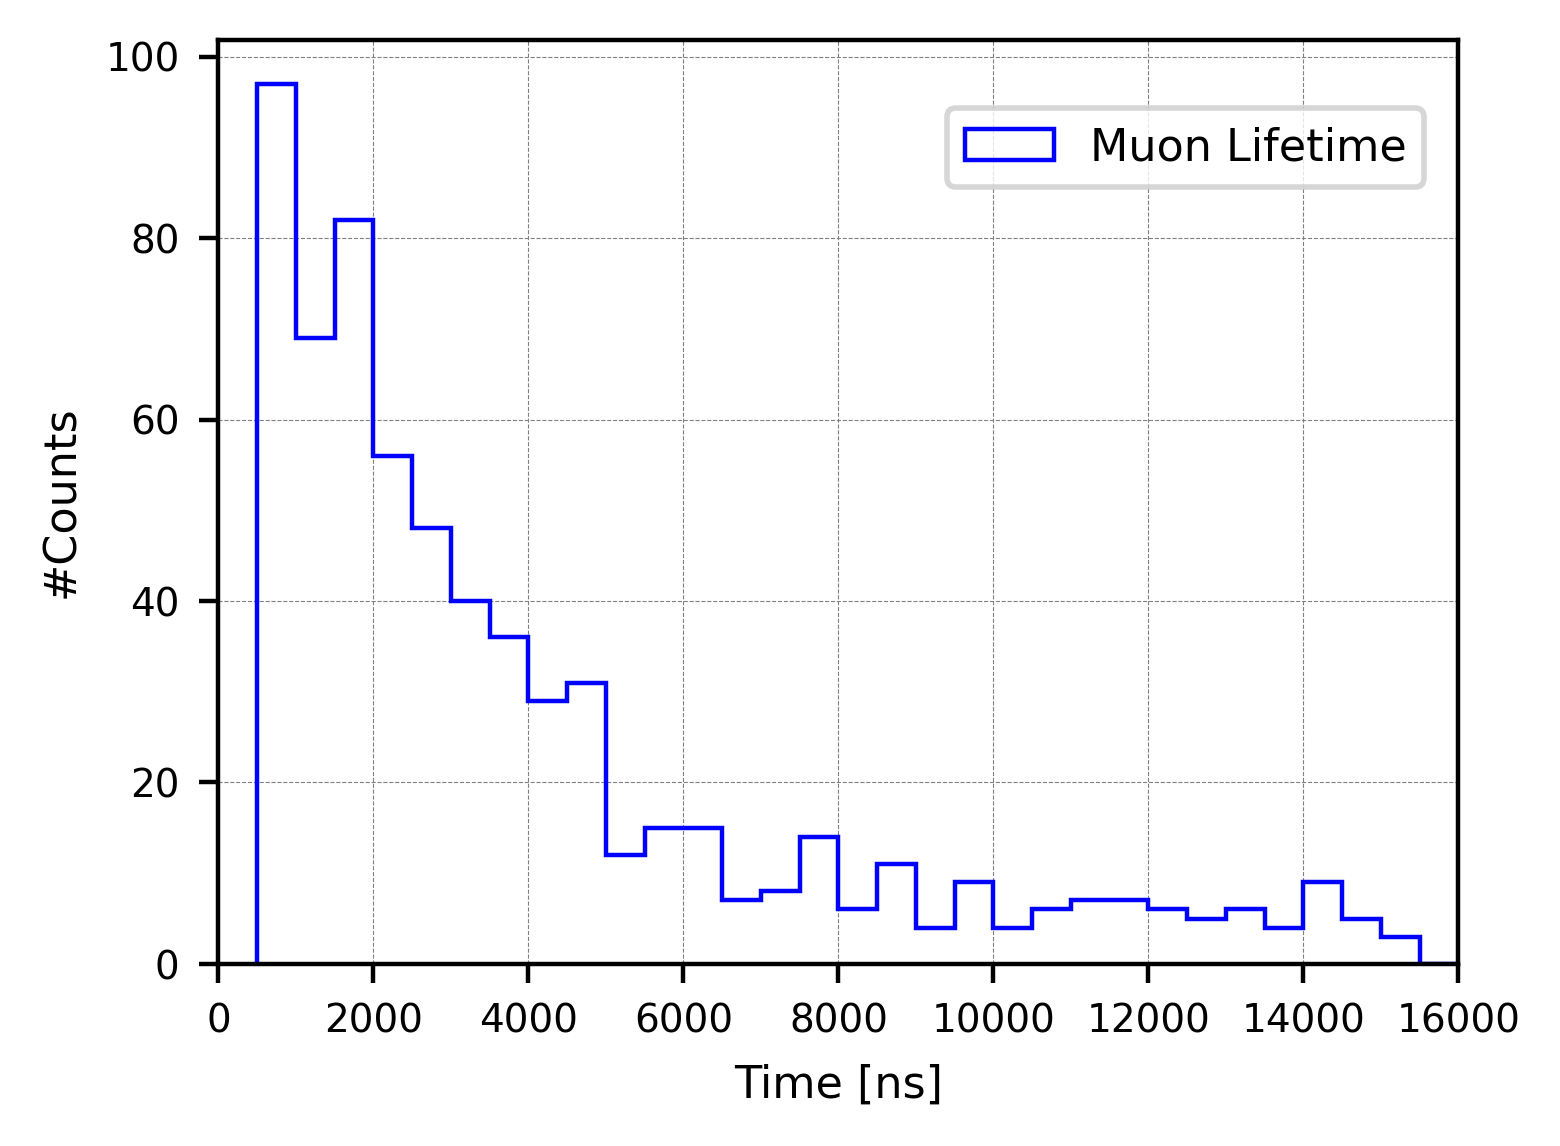


Least Square Fitting:==================

Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 97 ± 9.8
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 69 ± 8.3
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 82 ± 9.1
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 56 ± 7.5
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 48 ± 6.9
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 40 ± 6.3
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 36 ± 6.0
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 29 ± 5.4
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 31 ± 5.6
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 12 ± 3.5
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 15 ± 3.9
Bin 12: Range = [6000, 6500) | Center = 6250 ns | Entries = 15 ± 3.9
Bin 13: Range = [6500, 7000) | Center = 6750 ns | Entries = 7 ± 2.6
Bin 14: Range = [7000, 7500) | Center = 7250 ns | Entrie

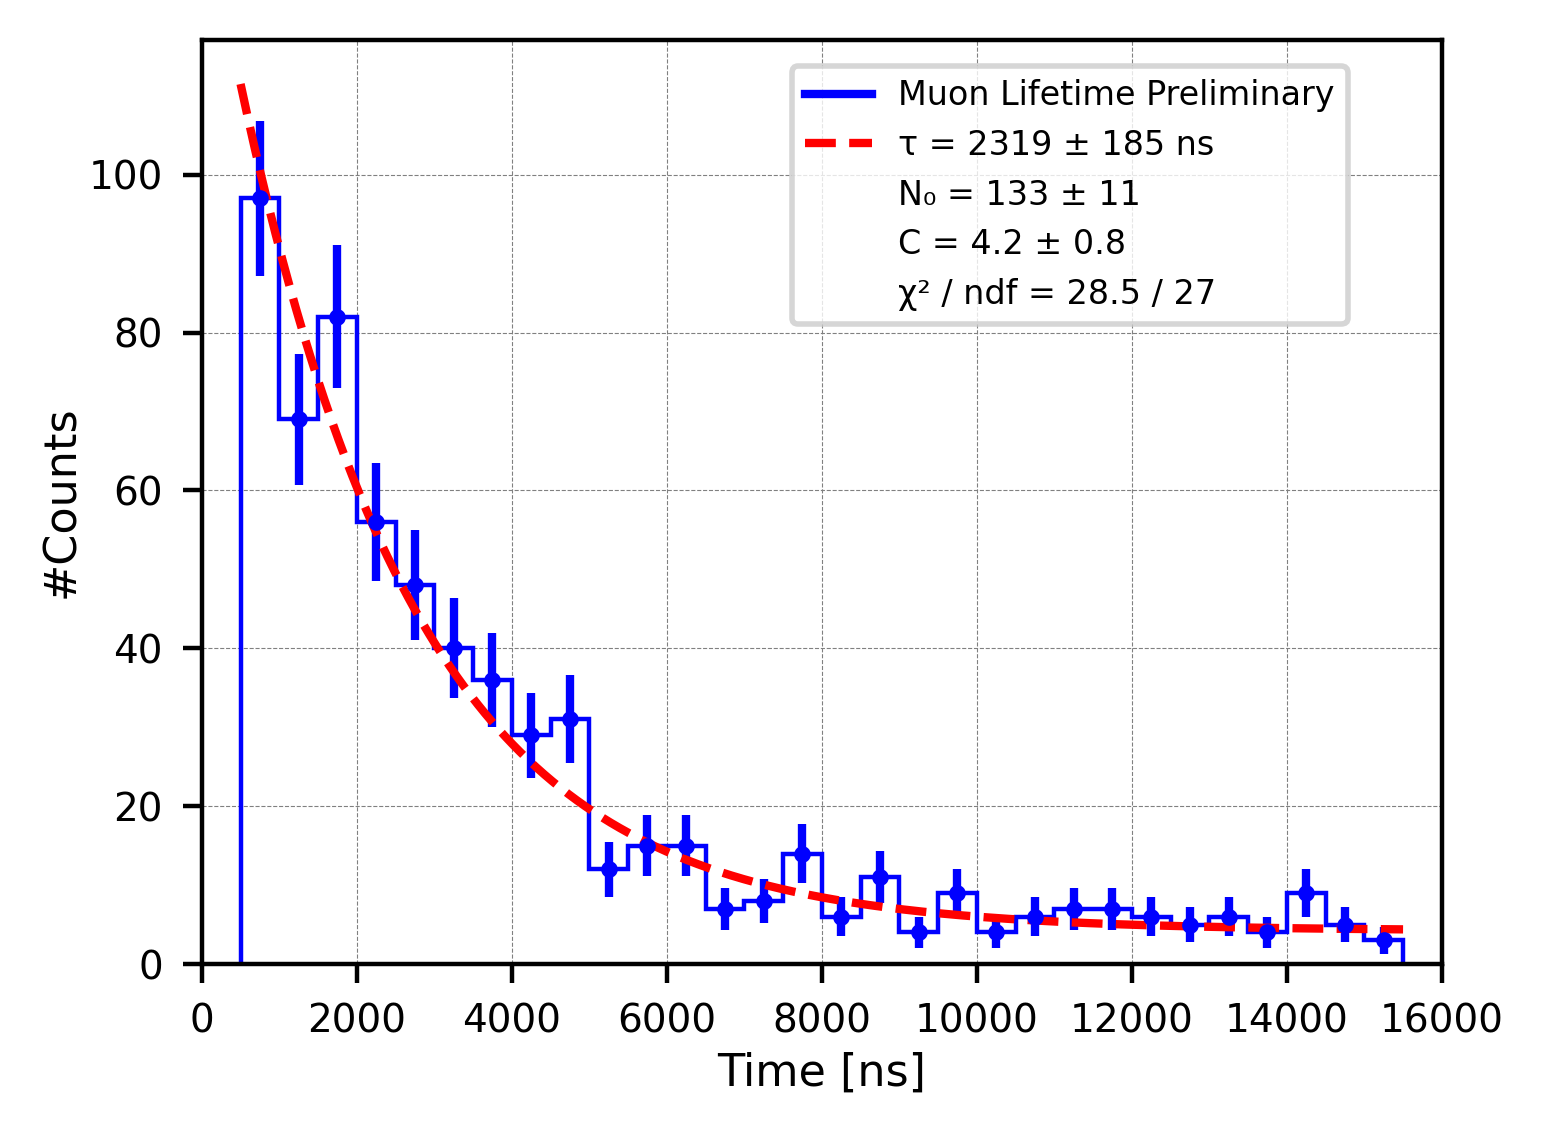

In [10]:
#Remove candidates with coincidence <3-----------------------------------------------
mu_lifetime_ns_purified = []

thre = 5

for i in range(0, len(peakFinder_miCoin)):
    coin = peakFinder_miCoin[i]
    time = mu_lifetime_ns[i]

    if coin >= thre:#-----------------
        mu_lifetime_ns_purified.append(time)
    
print("Keep #coincidence >= ", thre, ":")    
print("# Purified Candidates [-16000, 16000]: ", len(mu_lifetime_ns_purified))

#Test-------
mu_lifetime_ns_purified_00 = [val for val in mu_lifetime_ns_purified if 0 <= val <= 16000]
mu_lifetime_ns_purified_500 = [val for val in mu_lifetime_ns_purified if 500 <= val <= 16000]
print("# Purified Candidates [0, 16000]: ", len(mu_lifetime_ns_purified_00))
print("# Purified Candidates [500, 16000]: ", len(mu_lifetime_ns_purified_500))






# Muon Lifetime distribution (NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mu_lifetime_ns_purified_00, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Muon Lifetime')

plt.xlim(0, 16000)
#plt.ylim(0, 400)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()







#Plot---------------------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\nLeast Square Fitting:==================")

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Create the histogram and capture counts, bin edges, etc.
n, bin_edges, patches = plt.hist(mu_lifetime_ns_purified_500, bins=bins, range=(range_min, range_max),
                                 edgecolor='blue', histtype='step', linewidth=0.8,
                                 label='Muon Lifetime Preliminary')

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_plot = np.where(n == 0, 1, yerr)  # Avoid zero division error for empty bins

# Plot error bars on the histogram
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2)

# Define the exponential fitting function: N(t) = N0 * exp(-t/tau0) + C
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Least Squares Method------
popt, pcov = curve_fit(exp_func, bin_centers, n, p0=[max(n), 1000, 1], sigma=yerr, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties

# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")

# Print results to terminal
print("\nFitted parameters:")
print("N0 = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print("tau0 = {:.2f} +/- {:.2f} ns".format(popt[1], perr[1]))
print("C = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))

# Calculate chi-squared
expected = exp_func(bin_centers, *popt)
expected = np.clip(expected, 1e-10, None)  # Avoid division by zero
residuals = n - expected
chi2 = np.sum((residuals / yerr_plot) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

# Print goodness-of-fit summary
print(f"\n[Goodness of Fit] χ² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print detailed bin-by-bin information
for i, (label, observed, exp_val, res, err) in enumerate(zip(bin_centers, n, expected, residuals, yerr_plot)):
    print(f"Bin {i} (center={label:.2f}): n = {observed:.2f}; expected = {exp_val:.2f}; "
          f"residual = {res:.2f}; residual / yerr = {res / err:.2f}")

# Plot and legend----------
n0_text = f'N₀ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau_text = f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func(t_fit, *popt), color='red', linestyle='--', label=tau_text)

# Dummy handles for text-only legend entries
dummy_n0 = plt.Line2D([], [], color='none', label=n0_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

# Histogram handle
hist_handle = plt.Line2D([], [], color='blue', linestyle='-', label='Muon Lifetime Preliminary')

plt.legend(handles=[hist_handle, fit_line, dummy_n0, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
#plt.ylim(0.9, 400)
#plt.yscale('log')
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()




Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 1041 ± 32.3
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 796 ± 28.2
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 578 ± 24.0
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 427 ± 20.7
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 271 ± 16.5
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 198 ± 14.1
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 149 ± 12.2
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 121 ± 11.0
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 91 ± 9.5
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 50 ± 7.1
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 53 ± 7.3
Bin 12: Range = [6000, 6500) | Center = 6250 ns | Entries = 42 ± 6.5
Bin 13: Range = [6500, 7000) | Center = 6750 ns | Entries = 26 ± 5.1
Bin 14: Range = [7000, 7500) | Center = 7250 ns | Entries = 21 ± 4.6
Bin 15: Ra

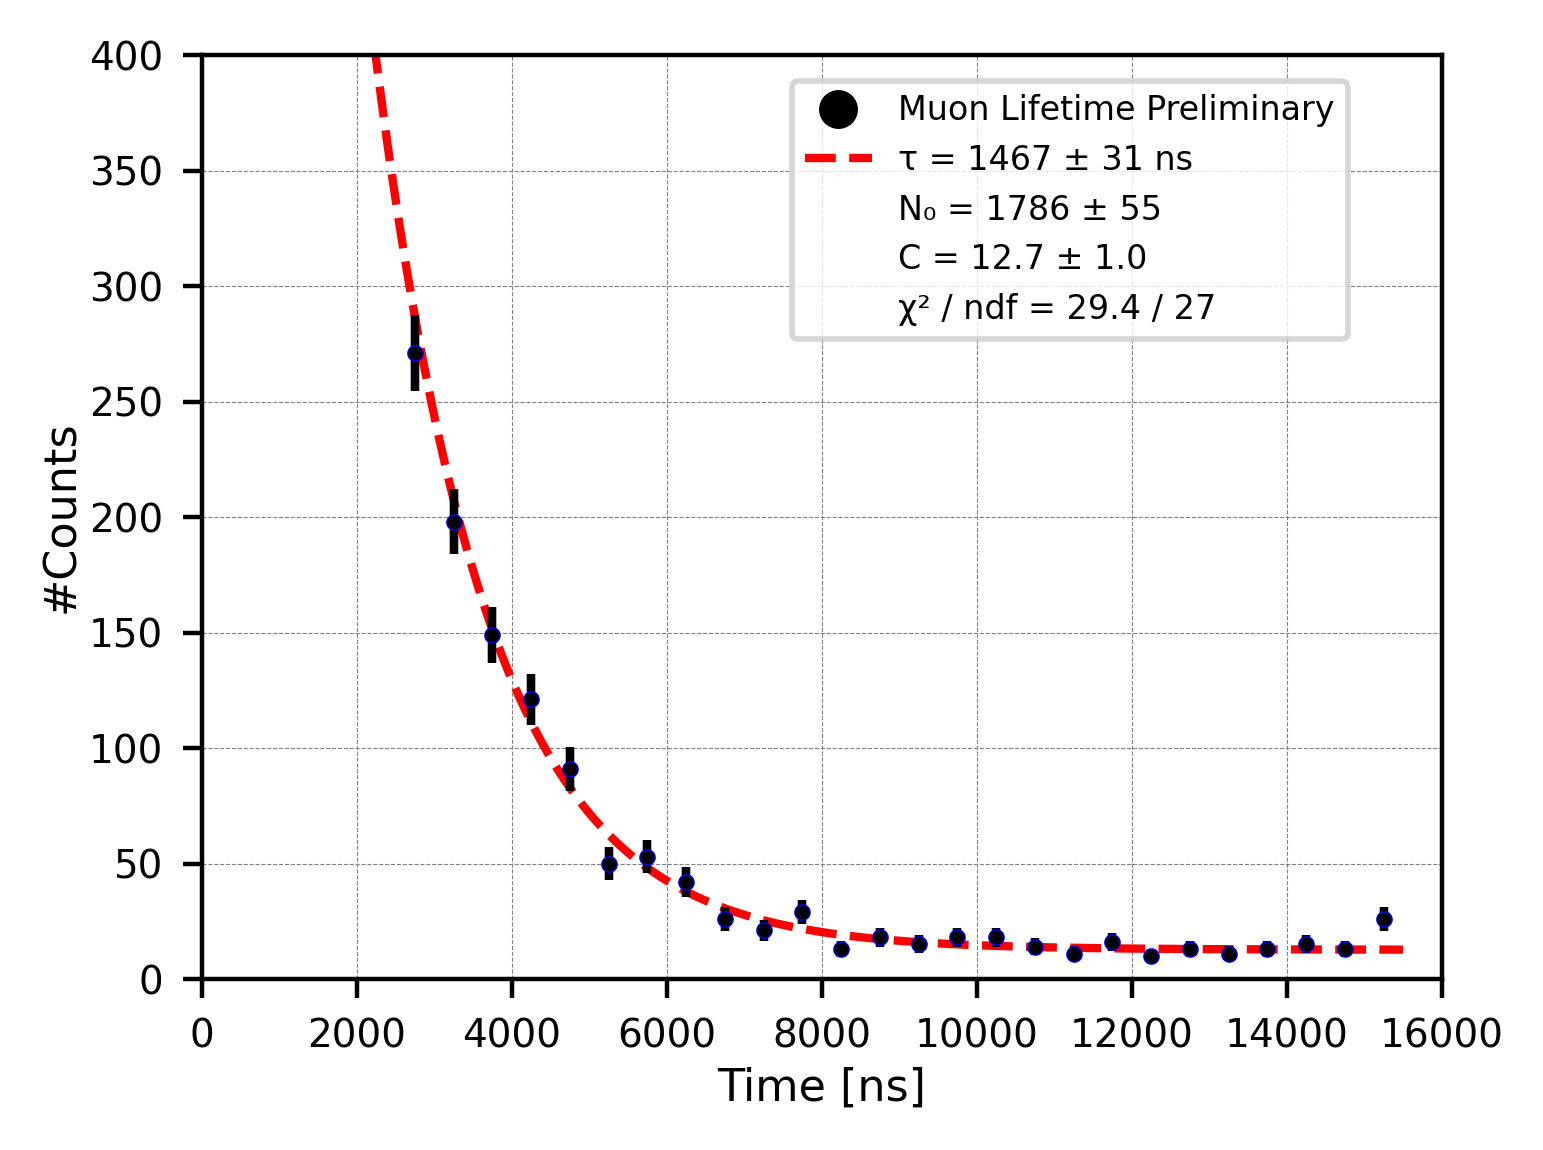

In [6]:
# Plot------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)


n, bin_edges = np.histogram(mu_lifetime_ns_purified_500, bins=bins, range=(range_min, range_max))


# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_weight = np.where(n == 0, 1, yerr)

# Plot error bars on the histogram
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2)

# Define the exponential fitting function: N(t) = N0 * exp(-t/tau0) + C
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C


#Least Squares Method------
popt, pcov = curve_fit(exp_func, bin_centers, n, p0=[max(n), 1000, 1], sigma=yerr_weight, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties



# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")



# Print results to terminal
print("\nFitted parameters:")
print("N0 = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print("tau0 = {:.2f} +/- {:.2f} ns".format(popt[1], perr[1]))
print("C = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))

# Calculate chi-squared
residuals = n - exp_func(bin_centers, *popt)
chi2 = np.sum((residuals / yerr_weight) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

# Plot and legend----------
n0_text = f'N₀ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau_text = f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func(t_fit, *popt), color='red', linestyle='--', label=tau_text)

# Dummy handles for text-only legend entries
dummy_n0 = plt.Line2D([], [], color='none', label=n0_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

#To remove line of histogram, 20250522---
# Histogram handle
#hist_handle = plt.Line2D([], [], color='blue', linestyle='-', label='Muon Lifetime Preliminary')

hist_handle = plt.Line2D([], [], color='black', marker='o', linestyle='', label='Muon Lifetime Preliminary')
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='black', markersize=1.5)


plt.legend(handles=[hist_handle, fit_line, dummy_n0, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
plt.ylim(0, 400)
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()